In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('/content/Salary_Data (1).csv')
df.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


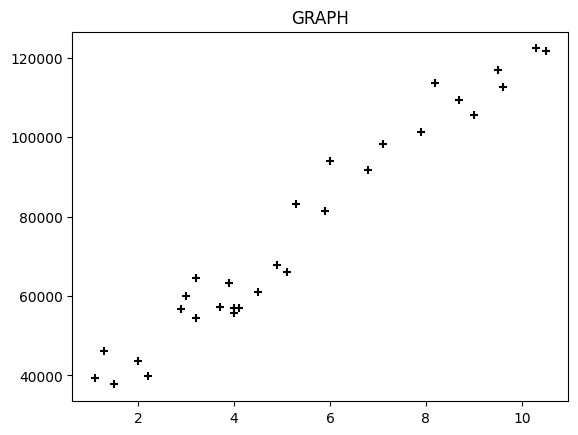

In [ ]:
plt.scatter(df['YearsExperience'],df['Salary'],color='black',marker='+')
plt.title('GRAPH')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
X = df['YearsExperience']
y = df['Salary']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train = X_train.values.reshape(-1, 1)
X_test = X_test.values.reshape(-1, 1)

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Mean Squared Error:", mse)
print("R-squared:", r2)

Mean Squared Error: 49830096.85590839
R-squared: 0.9024461774180497


In [ ]:
import joblib
joblib.dump(lr,'/content/Salary_Data (1).csv')
import gradio as gr
import numpy as np
model = joblib.load('/content/Salary_Data (1).csv')
def predict_salary(years_experience):
    input_data = np.array([[years_experience]])
    predicted_salary = model.predict(input_data)
    return predicted_salary[0]
iface = gr.Interface(fn=predict_salary,
                     inputs=gr.Number(label="YearsExperience"),
                     outputs=gr.Number(label="Salary"))
iface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c573aeebe3e3b12dc5.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
